# W2 and sliced-Wasserstein flows between silhouettes

This notebook generates `fig:generative-w2-vs-sliced-flow-shapes`.  The source law is sampled from the cat silhouette and the target law from the heart silhouette.  It compares two Wasserstein gradient flows for discrepancies to the same target law \(\beta\):

\[
    \mathcal E_{W_2}(\alpha)=\frac12 W_2^2(\alpha,\beta),
    \qquad
    \mathcal E_{\mathrm{SW}}(\alpha)=\frac12 \mathrm{SW}_2^2(\alpha,\beta).
\]

For the empirical \(W_2\) flow, the optimal assignment from the initial particles to the target particles gives the exact descent curves
\[
    x_i(t)=y_{\sigma(i)}+e^{-t}\bigl(x_i(0)-y_{\sigma(i)}\bigr).
\]
For the sliced-Wasserstein flow, the velocity is recomputed at each step by sorting projected particles along many directions,
\[
    \dot x_i(t)=\frac1L\sum_{\ell=1}^L
    \bigl(T_{\theta_\ell}(\theta_\ell^\top x_i(t))-\theta_\ell^\top x_i(t)\bigr)\theta_\ell .
\]
The left panels show representative particle trajectories; the right panels show five larger kernel-density snapshots with the book's red-to-blue time palette.

In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
from scipy.ndimage import gaussian_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial import cKDTree

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks-figures":
    ROOT = ROOT.parent
elif not (ROOT / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parents[0]
FIGROOT = ROOT / "notebooks-figures"
sys.path.insert(0, str(FIGROOT))

from figure_style import BLUE, RED, VIOLET, figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()

NAME = "generative-w2-vs-sliced-flow-shapes"
out = figure_dir(NAME)
thumb_dir = FIGROOT / "thumbnails"
thumb_dir.mkdir(exist_ok=True)
rng = np.random.default_rng(20260701)
assets = FIGROOT / "assets"

# Mirror the generated panels to the arXiv/PDE4ML figure folders as well.
arxiv_figures = ROOT / "arxiv" / "figures"
pde_figures = ROOT / "PDE4ML" / "figures" / NAME
pde_figures.mkdir(parents=True, exist_ok=True)
arxiv_figures.mkdir(parents=True, exist_ok=True)

## Shape samples

The two silhouettes are converted to foreground point clouds, normalized to a common coordinate system, and thinned by farthest-point sampling.  The numerical flow uses a denser farthest-point cloud than the visible trajectories; representative curves are selected by a second farthest-point pass so that the display covers the whole shape without becoming cluttered.

In [2]:
def foreground_pixels(path, *, max_candidates=90000):
    img = Image.open(path).convert("RGBA")
    arr = np.asarray(img)
    gray = np.asarray(img.convert("L"), dtype=float)
    alpha = arr[..., 3].astype(float)
    if alpha.max() - alpha.min() > 100 and alpha.min() < 80:
        mask = alpha > 80
    else:
        mask = gray < 238
    yy, xx = np.nonzero(mask)
    pts = np.column_stack([xx, -yy]).astype(float)
    pts -= pts.mean(axis=0, keepdims=True)
    pts /= max(np.linalg.norm(pts, axis=1).max(), 1e-12)
    if len(pts) > max_candidates:
        pts = pts[rng.choice(len(pts), max_candidates, replace=False)]
    return pts


def farthest_point_sample(points, n, *, seed=0, start="center"):
    local_rng = np.random.default_rng(seed)
    pts = np.asarray(points, dtype=float)
    idx = np.empty(n, dtype=int)
    if start == "random":
        idx[0] = int(local_rng.integers(len(pts)))
    else:
        center = pts.mean(axis=0)
        idx[0] = int(np.argmin(np.sum((pts - center) ** 2, axis=1)))
    dist2 = np.sum((pts - pts[idx[0]]) ** 2, axis=1)
    for k in range(1, n):
        idx[k] = int(np.argmax(dist2))
        dist2 = np.minimum(dist2, np.sum((pts - pts[idx[k]]) ** 2, axis=1))
    return pts[idx], idx


def robust_shape_normalization(points):
    pts = points - points.mean(axis=0, keepdims=True)
    lo, hi = np.percentile(pts, [0.5, 99.5], axis=0)
    scale = max(float(np.max(hi - lo)), 1e-12)
    return pts / scale


def normalize_pair(source, target):
    # Normalize each silhouette by a robust bounding-box diameter.  This removes
    # accidental scale differences in the bitmap assets while preserving each
    # silhouette's anisotropy.
    source = robust_shape_normalization(source)
    target = robust_shape_normalization(target)
    common_size = 1.72
    source = common_size * source
    target = common_size * target
    # A small common rotation avoids overly vertical trajectory bundles.
    ang = -0.10
    R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]])
    return source @ R.T, target @ R.T

cat_candidates = foreground_pixels(assets / "cat.png")
heart_candidates = foreground_pixels(assets / "heart.jpg")
cat_candidates, heart_candidates = normalize_pair(cat_candidates, heart_candidates)

N = 1800
X0, _ = farthest_point_sample(cat_candidates, N, seed=10)
Y, _ = farthest_point_sample(heart_candidates, N, seed=11)

# Tiny deterministic jitter breaks exact pixel-grid degeneracies without changing
# the silhouette geometry.
X0 = X0 + 0.0018 * rng.normal(size=X0.shape)
Y = Y + 0.0018 * rng.normal(size=Y.shape)

all_points = np.vstack([X0, Y])
center = 0.5 * (all_points.min(axis=0) + all_points.max(axis=0))
span = (all_points.max(axis=0) - all_points.min(axis=0)).max()
pad = 0.10 * span
xlim = (center[0] - 0.5 * span - pad, center[0] + 0.5 * span + pad)
ylim = (center[1] - 0.5 * span - pad, center[1] + 0.5 * span + pad)

print(f"source/target particles: {N}")
print(f"limits: {xlim}, {ylim}")


source/target particles: 1800
limits: (np.float64(-1.3265352149740175), np.float64(1.1123916907740026)), (np.float64(-1.2258134642565934), np.float64(1.2131134414914266))


## W2 and SW flows

The \(W_2\) dynamics uses the exact equal-weight assignment for the sampled clouds.  The sliced flow is an explicit Euler integration of the projected sorting formula.  The snapshots are indexed by normalized display times so both rows can be read with the same red-to-blue palette.

In [3]:
# Exact empirical W2 assignment and gradient-flow trajectory.
C = np.sum((X0[:, None, :] - Y[None, :, :]) ** 2, axis=2)
rows, cols = linear_sum_assignment(C)
perm = np.empty(N, dtype=int)
perm[rows] = cols
Ymatch = Y[perm]

# Display times are normalized to [0, 1], but W2 uses the exponential GF time.
tau_display = np.linspace(0.0, 1.0, 5)
T_w2 = 4.6
w2_snaps = np.stack([Ymatch + np.exp(-T_w2 * tau) * (X0 - Ymatch) for tau in tau_display])

# Sliced-Wasserstein empirical flow.
L = 224
angles = np.linspace(0.0, np.pi, L, endpoint=False)
directions = np.column_stack([np.cos(angles), np.sin(angles)])
Yproj_sorted = np.sort(Y @ directions.T, axis=0)


def sliced_velocity(X):
    proj = X @ directions.T
    vel = np.zeros_like(X)
    for ell, theta in enumerate(directions):
        order = np.argsort(proj[:, ell])
        disp_sorted = Yproj_sorted[:, ell] - proj[order, ell]
        disp = np.empty(N)
        disp[order] = disp_sorted
        vel += disp[:, None] * theta[None, :]
    return vel / L

T_sw = 16.0
steps = 420
dt = T_sw / steps
snap_steps = np.round(tau_display * steps).astype(int)
record_steps = np.unique(np.concatenate([snap_steps, np.arange(0, steps + 1, 5)]))

X = X0.copy()
sw_records = {}
for k in range(steps + 1):
    if k in record_steps:
        sw_records[k] = X.copy()
    if k == steps:
        break
    v = sliced_velocity(X)
    # Conservative explicit step with mild clipping for numerical smoothness.
    speed = np.linalg.norm(v, axis=1)
    vmax = np.quantile(speed, 0.995)
    if vmax > 1e-12:
        factor = np.minimum(1.0, 1.55 * vmax / (speed + 1e-12))
        v = v * factor[:, None]
    X = X + dt * v

sw_snaps = np.stack([sw_records[int(s)] for s in snap_steps])

# A denser cloud is used only for density rendering.  We lift it through the
# displacement field sampled by the computed particles, which gives smoother KDE
# snapshots without making the expensive sliced-flow solve several times larger.
N_density = 6400
X0_density, _ = farthest_point_sample(cat_candidates, N_density, seed=35, start="random")
X0_density = X0_density + 0.0012 * rng.normal(size=X0_density.shape)
nn_density = cKDTree(X0).query(X0_density)[1]
X0_anchor = X0[nn_density]

def lift_density_snaps(snaps):
    return X0_density[None, :, :] + (snaps[:, nn_density, :] - X0_anchor[None, :, :])

w2_density_snaps = lift_density_snaps(w2_snaps)
sw_density_snaps = lift_density_snaps(sw_snaps)
print(f"density rendering particles: {N_density}")

# Representative trajectories selected from the initial cloud.
trace_idx = farthest_point_sample(X0, 76, seed=24)[1]
record_order = sorted(sw_records)
sw_trace = np.stack([sw_records[k][trace_idx] for k in record_order])
w2_trace = np.stack([Ymatch[trace_idx] + np.exp(-T_w2 * (k / steps)) * (X0[trace_idx] - Ymatch[trace_idx]) for k in record_order])

# Diagnostics for the notebook output.
def mean_nn_distance(A, B):
    # Chunked nearest-neighbor distance to avoid an optional dependency.
    best = np.full(len(A), np.inf)
    chunk = 200
    for i in range(0, len(B), chunk):
        D = np.sum((A[:, None, :] - B[None, i:i + chunk, :]) ** 2, axis=2)
        best = np.minimum(best, D.min(axis=1))
    return float(np.sqrt(best).mean())

print(f"W2 final matched mean distance: {np.linalg.norm(w2_snaps[-1] - Ymatch, axis=1).mean():.4f}")
print(f"SW final mean nearest-target distance: {mean_nn_distance(sw_snaps[-1], Y):.4f}")


density rendering particles: 6400
W2 final matched mean distance: 0.0024
SW final mean nearest-target distance: 0.0144


## Rendering helpers

Each PDF panel is exported without an embedded title.  LaTeX supplies the row labels and panel explanation in the caption.  The density panels use a KDE only for rendering; the particle dynamics above is independent of the displayed smoothing.

In [4]:
ng = 340
x_edges = np.linspace(*xlim, ng + 1)
y_edges = np.linspace(*ylim, ng + 1)
xs = 0.5 * (x_edges[:-1] + x_edges[1:])
ys = 0.5 * (y_edges[:-1] + y_edges[1:])
dx = xs[1] - xs[0]
dy = ys[1] - ys[0]
XX, YY = np.meshgrid(xs, ys)
render_sigma = 4.6


def density_from_points(P, sigma=render_sigma):
    H, _, _ = np.histogram2d(P[:, 1], P[:, 0], bins=[y_edges, x_edges])
    Z = gaussian_filter(H.astype(float), sigma=sigma, mode="constant")
    if Z.sum() > 0:
        Z = Z / (Z.sum() * dx * dy)
    return Z


def time_cmap(t):
    color = interp_color(float(t))
    return LinearSegmentedColormap.from_list("time-cmap", [(1, 1, 1, 1), (*color, 0.12), (*color, 1.0)])


def format_axis(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_shape_context(ax):
    Z0 = density_from_points(X0, sigma=5.4)
    Z1 = density_from_points(Y, sigma=5.4)
    lev0 = [0.22 * Z0.max(), 0.54 * Z0.max()]
    lev1 = [0.22 * Z1.max(), 0.54 * Z1.max()]
    ax.contour(XX, YY, Z0, levels=lev0, colors=RED, linewidths=0.34, alpha=0.23, zorder=1)
    ax.contour(XX, YY, Z1, levels=lev1, colors=BLUE, linewidths=0.36, alpha=0.26, zorder=1)


def draw_trajectories(ax, trace):
    draw_shape_context(ax)
    segments = []
    colors = []
    nt = trace.shape[0]
    for i in range(trace.shape[1]):
        pts = trace[:, i, :]
        for k in range(nt - 1):
            segments.append([pts[k], pts[k + 1]])
            colors.append((*interp_color(k / max(nt - 2, 1)), 0.56))
    lc = LineCollection(segments, colors=colors, linewidths=0.50, zorder=3)
    ax.add_collection(lc)
    ax.scatter(trace[0, :, 0], trace[0, :, 1], s=2.0, color=RED, edgecolor="none", alpha=0.82, zorder=4)
    ax.scatter(trace[-1, :, 0], trace[-1, :, 1], s=2.0, color=BLUE, edgecolor="none", alpha=0.84, zorder=5)
    format_axis(ax)


def draw_density(ax, points, tau):
    Z = density_from_points(points)
    positive = Z[Z > 0]
    vmax = np.quantile(positive, 0.988) if len(positive) else 1.0
    Zshow = np.where(Z < 0.004 * vmax, 0.0, np.clip(Z, 0, vmax))
    ax.imshow(
        Zshow,
        origin="lower",
        extent=[*xlim, *ylim],
        cmap=time_cmap(tau),
        interpolation="bilinear",
        vmin=0,
        vmax=vmax,
    )
    levels = np.linspace(0.27 * vmax, 0.76 * vmax, 3)
    ax.contour(xs, ys, Z, levels=levels, colors="#2b2b2b", linewidths=0.22, alpha=0.24)
    format_axis(ax)


def save_and_mirror(fig, filename, *, pad_inches=0.006):
    pdf = out / filename
    save_pdf(fig, pdf, pad_inches=pad_inches)
    shutil.copy2(pdf, pde_figures / filename)
    shutil.copy2(pdf, arxiv_figures / f"{NAME}--{Path(filename).stem}.pdf")

# Individual panels for LaTeX layout.
for method, trace, snaps in [("w2", w2_trace, w2_density_snaps), ("sw", sw_trace, sw_density_snaps)]:
    fig, ax = plt.subplots(figsize=(1.86, 1.86))
    draw_trajectories(ax, trace)
    save_and_mirror(fig, f"{method}-trajectories.pdf", pad_inches=0.006)
    plt.close(fig)
    for i, (tau, pts) in enumerate(zip(tau_display, snaps)):
        fig, ax = plt.subplots(figsize=(1.15, 1.15))
        draw_density(ax, pts, tau)
        save_and_mirror(fig, f"{method}-density-{i}.pdf", pad_inches=0.004)
        plt.close(fig)

# Gallery thumbnail.
fig = plt.figure(figsize=(7.35, 2.55))
gs = fig.add_gridspec(2, 6, width_ratios=[1.38, 1, 1, 1, 1, 1], wspace=0.018, hspace=0.030)
for r, (trace, snaps) in enumerate([(w2_trace, w2_density_snaps), (sw_trace, sw_density_snaps)]):
    ax = fig.add_subplot(gs[r, 0])
    draw_trajectories(ax, trace)
    for j, (tau, pts) in enumerate(zip(tau_display, snaps)):
        ax = fig.add_subplot(gs[r, j + 1])
        draw_density(ax, pts, tau)
fig.savefig(thumb_dir / f"{NAME}.png", dpi=230, bbox_inches="tight", pad_inches=0.020)
plt.close(fig)

print(f"Wrote panels to {out}")
print(f"Wrote thumbnail to {thumb_dir / (NAME + '.png')}")


Wrote panels to /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/generative-w2-vs-sliced-flow-shapes
Wrote thumbnail to /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/generative-w2-vs-sliced-flow-shapes.png


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.

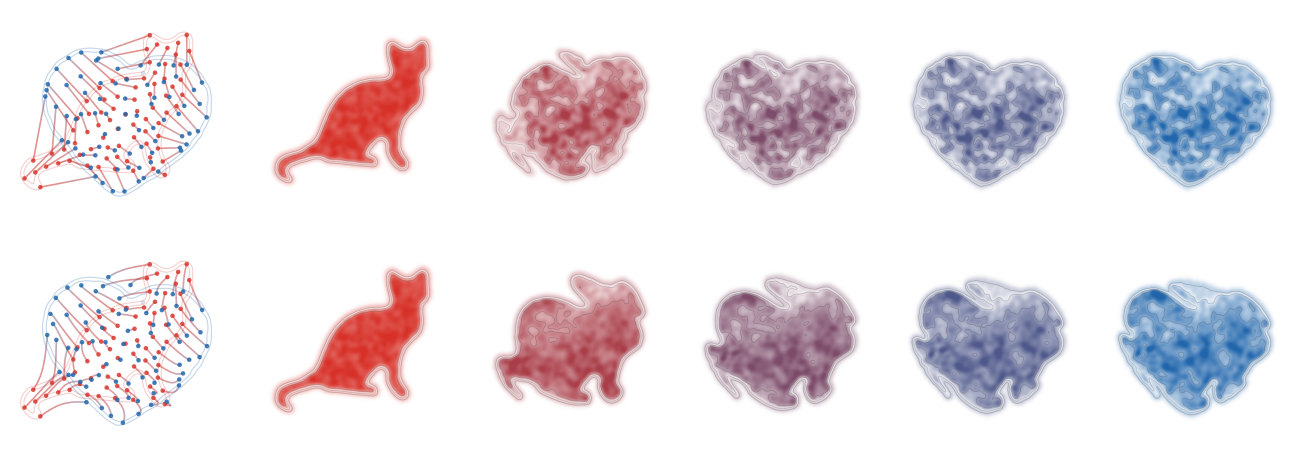

In [5]:
from IPython.display import Image as IPImage, display
_thumb = Path("thumbnails/generative-w2-vs-sliced-flow-shapes.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/generative-w2-vs-sliced-flow-shapes.png")
display(IPImage(filename=str(_thumb)))